In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
opening = pd.read_pickle("../output/data/48hr_averages/open_avg48hrs.pkl")

In [3]:
# Saving plots as pdf, png and svg
FIGURE_DIR = "../output/figures/clustering"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_figure(filename_stem, directory=FIGURE_DIR):
    """Save the current matplotlib figure as pdf, png and svg."""
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

In [4]:
path= "../output/data/matrices/z_work_weekly_gaussian.pkl"
work_matrix_gaus = pd.read_pickle(path)

In [5]:
# Drop raster_ids with missing hours
work_matrix_gaus.dropna(inplace=True)

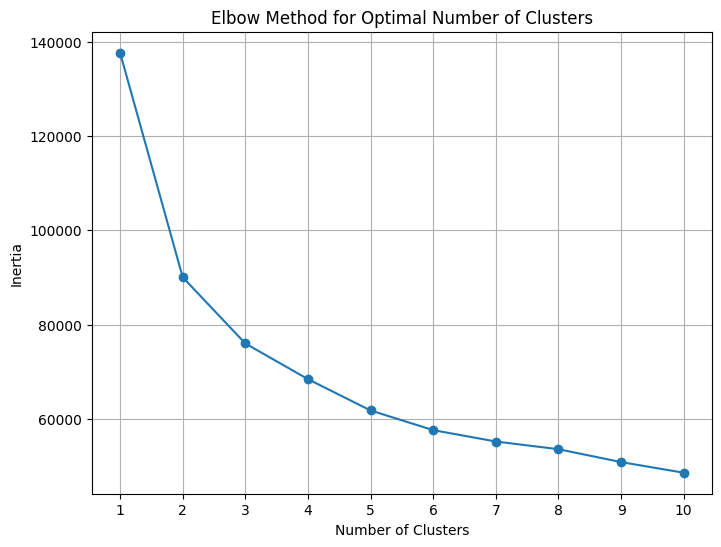

In [6]:
# Initialize lists to store inertia values and number of clusters
inertia_values = []
num_clusters_list = range(1, 11) 

# Calculate inertia for different numbers of clusters
for num_clusters in num_clusters_list:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(work_matrix_gaus)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(num_clusters_list, inertia_values, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xticks(num_clusters_list)
plt.grid(True)
save_figure("open_work_cluster_elbow")
plt.show()

In [7]:
N_CLUSTERS = 3
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)
work_cluster_labels = kmeans.fit_predict(work_matrix_gaus)

# Map raster_id -> cluster number
work_cluster_label_dict = dict(zip(work_matrix_gaus.index, work_cluster_labels))

In [8]:
cluster_label_map = {
    0: 'Mixed Shift cluster',
    1: 'Day Shift cluster',
    2: 'Weekend Shift cluster',
}

In [9]:
# Load the 48hr average data and add the cluster number and label back onto it
opening['work_cluster'] = opening['raster_id'].map(work_cluster_label_dict)
opening['work_cluster_label'] = opening['work_cluster'].map(cluster_label_map)

In [10]:
opening.to_pickle("../output/data/48hr_averages/open_avg48hrs_clustered.pkl")

# Plot temporal cluster

In [11]:
def plot_cluster_temporal_data(data, labels, n_clusters, filename_stem, label_map=None):
    """Plot each cluster's individual temporal sequences with the cluster mean
    overlaid (red), one subplot per cluster, and save the figure (pdf/png/svg)."""
    # Calculate average value for each cluster
    cluster_avg = []
    for cluster in range(n_clusters):
        cluster_data = data[labels == cluster]
        avg_value = np.mean(cluster_data, axis=0)
        cluster_avg.append(avg_value)

    # Plot temporal data for each cluster
    fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 6), sharex=True)

    for cluster in range(n_clusters):
        ax = axes[cluster]
        cluster_data = data[labels == cluster]
        ax.plot(cluster_data.T, color='blue', alpha=0.3)
        ax.plot(cluster_avg[cluster], color='red', linewidth=2)
        title = f'Cluster {cluster}'
        if label_map is not None:
            title += f': {label_map.get(cluster, "")}'
        ax.set_title(title)
        ax.set_ylabel('Value')

    # Adjust xticks to go from 0-23 and then repeat (weekday + weekend)
    xtick_labels = list(range(24)) + list(range(24))  # 0-23 twice
    axes[-1].set_xticks(list(range(48)))
    axes[-1].set_xticklabels(xtick_labels, fontsize=8)

    # Add "Weekday" and "Weekend" labels below the last subplot
    y_min, y_max = axes[-1].get_ylim()
    y_offset = y_min - (y_max - y_min) * 0.25
    axes[-1].text(12, y_offset, 'Weekday', ha='center', va='top', fontsize=10, clip_on=False)
    axes[-1].text(36, y_offset, 'Weekend', ha='center', va='top', fontsize=10, clip_on=False)

    axes[-1].set_xlabel('Hour')

    plt.tight_layout()
    save_figure(filename_stem)
    plt.show()

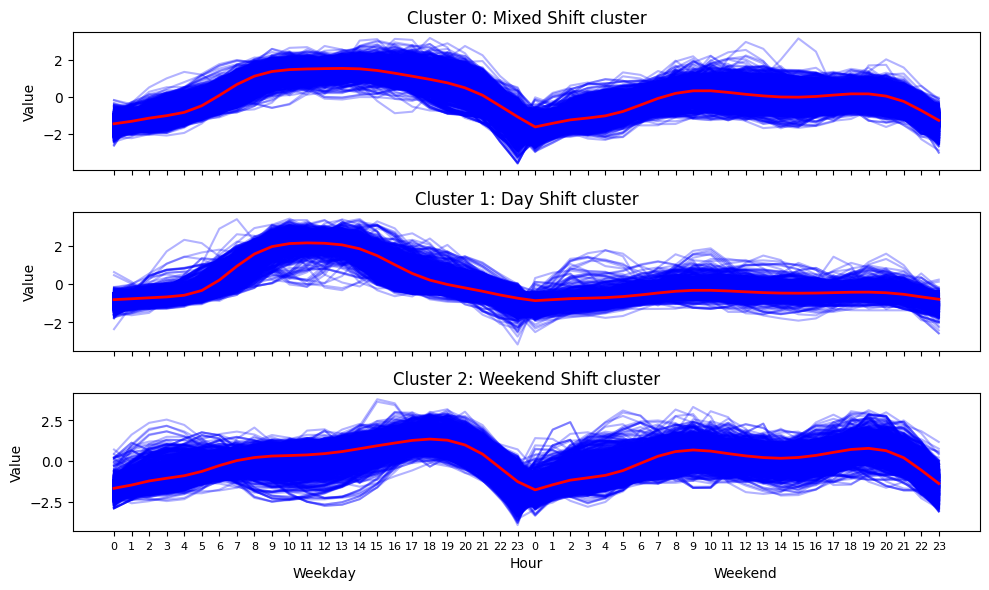

In [12]:
plot_cluster_temporal_data(
    work_matrix_gaus,
    work_cluster_labels,
    N_CLUSTERS,
    "open_work_3clust_temporal",
    label_map=cluster_label_map
)